# DimeNet++ Embedded Internal-Alpha/Beta HOMO-LUMO Gap

Custom DimeNet++ that injects Lowdin charges + electronegativity **inside** the
forward pass (like SchNet Embedded does), not as a residual at the output.

Key insight: DimeNet++ uses edge embeddings, but the OutputBlocks scatter to
node-level before summing to molecule-level. We inject atom features into the
OutputBlock pathway so they flow through the output MLPs.

- Lowdin + electronegativity injected into output block node representations
- Spin conditioning on final molecular representation
- All tuning wins + EMA/checkpoint fallback + warmup

In [ ]:
# Install dependencies
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install -q ase
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"
!pip install -q lmdb ase-db-backends e3nn hydra-core pymatgen submitit torchtnt

print("RESTART THE RUNTIME SESSION NOW")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 111.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 143.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 47.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import DimeNetPlusPlus, radius_graph
from torch_geometric.loader import DataLoader
from torch_geometric.utils import scatter
from torch_geometric.typing import SparseTensor
from read_multi_ase_att import *
from extract_ab_att_emb import *

## Model

We manually run DimeNet++'s forward pass so we can inject extra atom features
into the node-level representations before the final scatter to molecule level.
This mirrors how SchNet Embedded adds features before message passing.

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        model.load_state_dict(self.shadow)


def triplets(edge_index, num_nodes):
    row, col = edge_index
    value = torch.arange(row.size(0), device=row.device)
    adj_t = SparseTensor(row=col, col=row, value=value,
                         sparse_sizes=(num_nodes, num_nodes))
    adj_t_row = adj_t[row]
    num_triplets = adj_t_row.set_value(None).sum(dim=1).to(torch.long)

    idx_i = col.repeat_interleave(num_triplets)
    idx_j = row.repeat_interleave(num_triplets)
    idx_k = adj_t_row.storage.col()
    mask = idx_i != idx_k
    idx_i, idx_j, idx_k = idx_i[mask], idx_j[mask], idx_k[mask]

    idx_kj = adj_t_row.storage.value()[mask]
    idx_ji = adj_t_row.storage.row()[mask]

    return col, row, idx_i, idx_j, idx_k, idx_kj, idx_ji


class DimeNetPP_Embedded(nn.Module):
    """DimeNet++ with features injected inside the forward pass.

    Extra atom features (Lowdin + EN) are projected and added to the
    node-level representation inside each output block, so they
    influence the output MLPs directly.
    """
    def __init__(self, hidden_channels=64, out_channels=2, num_blocks=4,
                 int_emb_size=64, basis_emb_size=8, out_emb_channels=128,
                 num_spherical=7, num_radial=6, cutoff=7.0,
                 extra_feat_dim=2, train_mean=None, train_std=None):
        super().__init__()
        self.cutoff = cutoff
        self.max_num_neighbors = 32
        self.num_blocks = num_blocks

        # Use DimeNet++ but we'll run forward manually
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=basis_emb_size,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
        )

        # Project extra features to hidden_channels (added to edge embeddings)
        self.feat_proj = nn.Linear(extra_feat_dim, hidden_channels)

        # Spin conditioning on molecule-level output
        self.spin_proj = nn.Linear(1, out_channels)

        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        z, pos, batch = data.z, data.pos, data.batch
        extra_feat = data.extra_feat

        # Build graph
        edge_index = radius_graph(pos, r=self.cutoff, batch=batch,
                                  max_num_neighbors=self.max_num_neighbors)
        i, j, idx_i, idx_j, idx_k, idx_kj, idx_ji = triplets(
            edge_index, num_nodes=z.size(0))

        # Distances and angles
        dist = (pos[i] - pos[j]).pow(2).sum(dim=-1).sqrt()
        pos_jk = pos[idx_j] - pos[idx_k]
        pos_ij = pos[idx_i] - pos[idx_j]
        a = (pos_ij * pos_jk).sum(dim=-1)
        b = torch.cross(pos_ij, pos_jk).norm(dim=-1)
        angle = torch.atan2(b, a)

        # Basis functions
        rbf = self.dimenet.rbf(dist)
        sbf = self.dimenet.sbf(dist, angle, idx_kj)

        # Embedding block (edge-level)
        x = self.dimenet.emb(z, rbf, i, j)

        # === INJECT FEATURES ===
        # Project per-atom features and add to edge embeddings
        # Each edge (i,j) gets features from both atoms i and j
        feat_node = self.feat_proj(extra_feat)  # [num_atoms, hidden]
        x = x + feat_node[i] + feat_node[j]  # add to edge embeddings

        # Output from first block
        P = self.dimenet.output_blocks[0](x, rbf, i, num_nodes=pos.size(0))

        # Interaction blocks
        for interaction_block, output_block in zip(
            self.dimenet.interaction_blocks, self.dimenet.output_blocks[1:]):
            x = interaction_block(x, rbf, sbf, idx_kj, idx_ji)
            P = P + output_block(x, rbf, i, num_nodes=pos.size(0))

        # Scatter to molecule level
        out = scatter(P, batch, dim=0, reduce='sum')

        # Spin conditioning
        spin = data.spin.unsqueeze(-1).float()
        out = out + self.spin_proj(spin)

        return out

## Training and Evaluation

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        ema.update(model)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_mae = 0
    total_mse = 0
    n = 0
    mean = model.mean.to(device)
    std = model.std.to(device)
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        pred_eV = (pred * std + mean) * mask
        target_eV = (target * std + mean) * mask
        total_mae += torch.abs(pred_eV - target_eV).sum().item()
        total_mse += ((pred_eV - target_eV) ** 2).sum().item()
        n += mask.sum().item()
    return total_mae / n, (total_mse / n) ** 0.5


def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('DimeNet++ Embedded Alpha/Beta Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Data Loading — 10000 Biomolecules

In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

Processed 10000 molecules
Train: 6400, Val: 1600, Test: 2000
Mean: tensor([8.2063, 6.8922]), Std: tensor([2.0472, 2.0885])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_Embedded(
    hidden_channels=64,
    out_channels=2,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=6,
    cutoff=7.0,
    extra_feat_dim=2,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 499,082


## Training with Warmup

In [ ]:
epochs = 400
patience = 50
warmup_epochs = 5
base_lr = 1e-3
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    if epoch < warmup_epochs:
        warmup_lr = base_lr * (epoch + 1) / warmup_epochs
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)

    if epoch >= warmup_epochs:
        scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | LR: {lr:.1e} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Test both EMA and best checkpoint
ema.apply(model)
mae_ema, _ = test(model, bio_val_loader)
model.load_state_dict(best_state)
mae_best, _ = test(model, bio_val_loader)

if mae_ema < mae_best:
    ema.apply(model)
    print(f"Using EMA weights (val MAE: {mae_ema:.4f})")
else:
    print(f"Using best checkpoint (val MAE: {mae_best:.4f})")

print(f"Best Val Loss: {best_val:.4f}")

/tmp/ipykernel_8901/2407426487.py:87: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  b = torch.cross(pos_ij, pos_jk).norm(dim=-1)


Epoch 001 | Train: 216.6710 | Val: 0.4185 | LR: 2.0e-04 | Patience: 0/50
Epoch 011 | Train: 0.2428 | Val: 0.2290 | LR: 1.0e-03 | Patience: 0/50
Epoch 021 | Train: 0.3787 | Val: 0.1806 | LR: 1.0e-03 | Patience: 2/50
Epoch 031 | Train: 0.1249 | Val: 0.1856 | LR: 1.0e-03 | Patience: 3/50
Epoch 041 | Train: 0.1798 | Val: 0.1686 | LR: 1.0e-03 | Patience: 9/50
Epoch 051 | Train: 0.0437 | Val: 0.1736 | LR: 5.0e-04 | Patience: 19/50
Epoch 061 | Train: 0.0196 | Val: 0.1798 | LR: 2.5e-04 | Patience: 29/50
Epoch 071 | Train: 0.0110 | Val: 0.1899 | LR: 1.3e-04 | Patience: 39/50
Epoch 081 | Train: 0.0073 | Val: 0.1949 | LR: 6.3e-05 | Patience: 49/50
Early stopping at epoch 82
Using best checkpoint (val MAE: 0.8366)
Best Val Loss: 0.1607


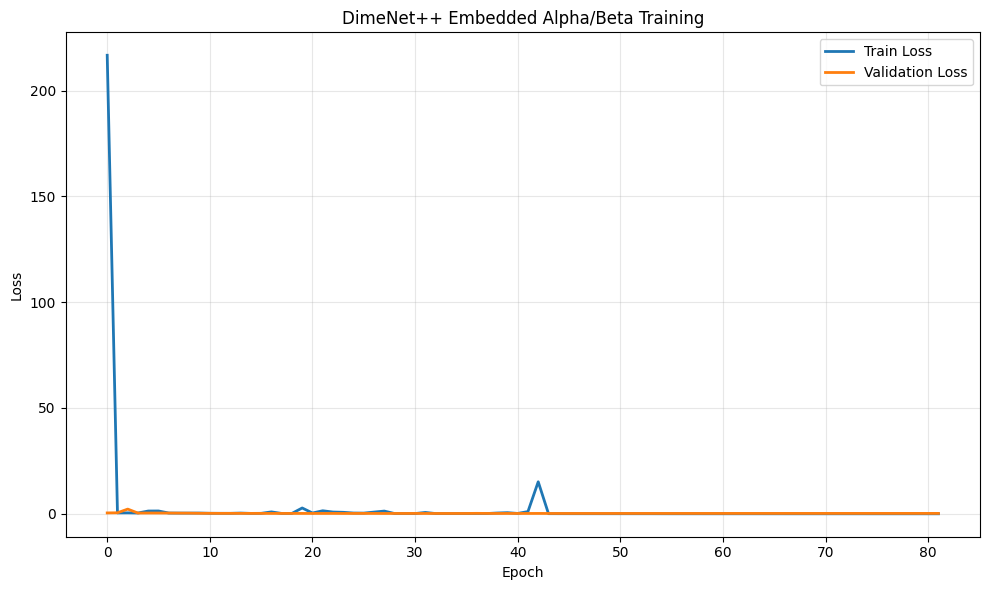

In [ ]:
plot_losses(train_losses, val_losses)

In [ ]:
mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.8727
Test RMSE: 1.3142
